In [1]:
import numpy as np
from pathlib import Path

import pandas as pd

In [16]:
bids_folder = Path('/data/ds-neuralpriors')
pars_ground_truth = pd.read_csv(bids_folder / 'derivatives' / 'encoding_models' / 'group_roi-NPCr_desc-groundtruth_parameters.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars_estimates = pd.read_csv(bids_folder / 'derivatives' / 'encoding_models' / 'group_roi-NPCr_desc-responses_parameters.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])

pars = pd.concat([pars_ground_truth, pars_estimates], keys=['ground_truth', 'estimates'], names=['type'], axis=0)

# rename index level subject_id to subject
pars.index.set_names('subject', level='subject_id', inplace=True)

pars.index.unique(level='smoothed')

Index([True], dtype='bool', name='smoothed')

In [17]:
pars = pars.xs(15, level='model_label').xs('ground_truth', level='type')
pars = pars[pars[('cvr2', 'nan')] > 0.0]

In [18]:
np.log(2)

0.6931471805599453

In [19]:
np.log(30)

3.4011973816621555

<Axes: xlabel="('sd', 'narrow')", ylabel='Count'>

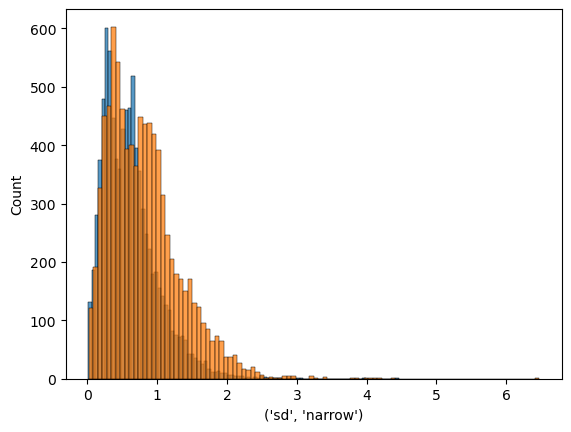

In [20]:
import seaborn as sns
sns.histplot(pars[('sd', 'narrow')])
sns.histplot(pars[('sd', 'wide')])

In [21]:
np.log(30)

3.4011973816621555

Text(0.5, 0, 'Preferred numerosity')

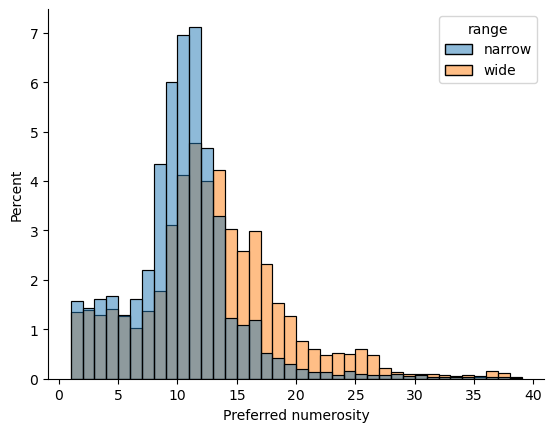

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(pars['mu'], bins=np.arange(1, 40), stat='percent')

sns.despine()

plt.xlabel("Preferred numerosity")

In [60]:
pars['lower_half'] = pars[('mu', 'narrow')] < ((25 - 10) / 2.)

In [64]:
pars.groupby('lower_half').apply(lambda d: (d[('mu', 'wide')] > d[('mu', 'narrow')]).mean())

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_68953/430093865.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  pars.groupby('lower_half').apply(lambda d: (d[('mu', 'wide')] > d[('mu', 'narrow')]).mean())
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_68953/430093865.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pars.groupby('lower_half').apply(lambda d: (d[('mu', 'wide')] > d[('mu', 'narrow')]).mean())


lower_half
False    0.778625
True     0.802146
dtype: float64

In [71]:
import pingouin as pg
pars.groupby(['subject', 'lower_half']).mean().groupby('lower_half').apply(lambda d: pg.ttest(d[('mu', 'wide')], d[('mu', 'narrow')], paired=True))

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_68953/2835423832.py:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  pars.groupby(['subject', 'lower_half']).mean().groupby('lower_half').apply(lambda d: pg.ttest(d[('mu', 'wide')], d[('mu', 'narrow')], paired=True))


,,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
lower_half,,,,,,,,,
False,T-test,4.075789,38,two-sided,2.253738e-04,"[1.25, 3.7]",0.577997,117.106,0.940264
True,T-test,5.918231,36,two-sided,8.937249e-07,"[1.16, 2.36]",0.935039,1.911e+04,0.999822


In [46]:
(pars['mu']['wide'] < pars['mu']['narrow']).mean()

0.18772917757988475

In [37]:
pars[('mu', 'narrow')].describe()

count    18523.000000
mean        11.656918
std          5.567103
min          0.004660
25%          9.118070
50%         11.306644
75%         13.636436
max         77.086784
Name: (mu, narrow), dtype: float64

In [24]:
pars[('mu', 'wide')].describe()

count    331939.000000
mean         14.275721
std           9.790676
min         -33.974415
25%           9.898272
50%          12.861670
75%          17.003146
max         218.914350
Name: (mu, wide), dtype: float64

In [17]:
(pars['mu'] == 10.0).mean()

range
narrow    0.000036
wide      0.000036
dtype: float64

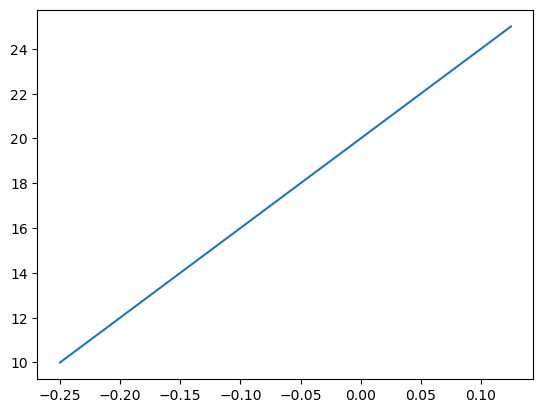

In [84]:

narrow_range = (10, 25)
wide_range = (10, 40)

narrow_width = narrow_range[1] - narrow_range[0]
wide_width = wide_range[1] - wide_range[0]

max_width = 50 - 10

prop_width_narrow = narrow_width / max_width
prop_width_wide = wide_width / max_width

plt.plot(np.arange(10, 26) / narrow_width * prop_width_narrow - 0.5, np.arange(10, 26), label='narrow')
# plt.plot((np.arange(10, 40) - 25) * prop_width_wide, np.arange(10, 40), label='wide')



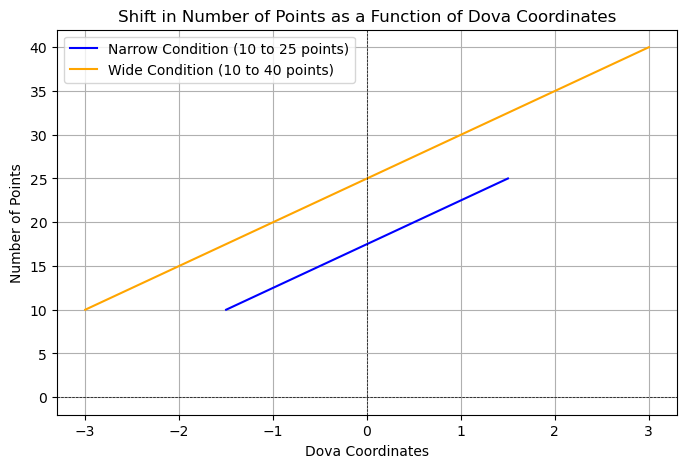

In [100]:
import matplotlib.pyplot as plt
import numpy as np

max_bar_width = 10
dova_per_unit = max_bar_width / 50  # Since the maximum range is 50 (40 - 10 for the wide condition)

# Define the mapping function
def points_to_dova(points, condition='narrow'):
    assert condition in ['narrow', 'wide'], "Condition must be 'narrow' or 'wide'"

    if condition == 'narrow':
        range_center = (10 + 25) / 2  # Middle of the narrow range
    elif condition == 'wide':
        range_center = (10 + 40) / 2  # Middle of the wide range

    return (points - range_center) * dova_per_unit

# Define the ranges for both conditions in points
points_condition1 = np.linspace(10, 25, 100)
points_condition2 = np.linspace(10, 40, 100)

# Calculate the corresponding dova values
dova_condition1 = points_to_dova(points_condition1, condition='narrow')
dova_condition2 = points_to_dova(points_condition2, condition='wide')

# Plot
plt.figure(figsize=(8, 5))
plt.plot(dova_condition1, points_condition1, label='Narrow Condition (10 to 25 points)', color='blue')
plt.plot(dova_condition2, points_condition2, label='Wide Condition (10 to 40 points)', color='orange')

# Add labels and title
plt.xlabel('Dova Coordinates')
plt.ylabel('Number of Points')
plt.title('Shift in Number of Points as a Function of Dova Coordinates')
plt.legend()
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')

# Show the plot
plt.show()


In [98]:
narrow_range, wide_range = (10, 25), (10, 40)
narrow_width = narrow_range[1] - narrow_range[0]
wide_width = wide_range[1] - wide_range[0]

narrow_width

15

In [96]:
points_condition1

array([10.        , 10.15151515, 10.3030303 , 10.45454545, 10.60606061,
       10.75757576, 10.90909091, 11.06060606, 11.21212121, 11.36363636,
       11.51515152, 11.66666667, 11.81818182, 11.96969697, 12.12121212,
       12.27272727, 12.42424242, 12.57575758, 12.72727273, 12.87878788,
       13.03030303, 13.18181818, 13.33333333, 13.48484848, 13.63636364,
       13.78787879, 13.93939394, 14.09090909, 14.24242424, 14.39393939,
       14.54545455, 14.6969697 , 14.84848485, 15.        , 15.15151515,
       15.3030303 , 15.45454545, 15.60606061, 15.75757576, 15.90909091,
       16.06060606, 16.21212121, 16.36363636, 16.51515152, 16.66666667,
       16.81818182, 16.96969697, 17.12121212, 17.27272727, 17.42424242,
       17.57575758, 17.72727273, 17.87878788, 18.03030303, 18.18181818,
       18.33333333, 18.48484848, 18.63636364, 18.78787879, 18.93939394,
       19.09090909, 19.24242424, 19.39393939, 19.54545455, 19.6969697 ,
       19.84848485, 20.        , 20.15151515, 20.3030303 , 20.45

In [95]:
dova_condition1

array([0.625     , 0.66287879, 0.70075758, 0.73863636, 0.77651515,
       0.81439394, 0.85227273, 0.89015152, 0.9280303 , 0.96590909,
       1.00378788, 1.04166667, 1.07954545, 1.11742424, 1.15530303,
       1.19318182, 1.23106061, 1.26893939, 1.30681818, 1.34469697,
       1.38257576, 1.42045455, 1.45833333, 1.49621212, 1.53409091,
       1.5719697 , 1.60984848, 1.64772727, 1.68560606, 1.72348485,
       1.76136364, 1.79924242, 1.83712121, 1.875     , 1.91287879,
       1.95075758, 1.98863636, 2.02651515, 2.06439394, 2.10227273,
       2.14015152, 2.1780303 , 2.21590909, 2.25378788, 2.29166667,
       2.32954545, 2.36742424, 2.40530303, 2.44318182, 2.48106061,
       2.51893939, 2.55681818, 2.59469697, 2.63257576, 2.67045455,
       2.70833333, 2.74621212, 2.78409091, 2.8219697 , 2.85984848,
       2.89772727, 2.93560606, 2.97348485, 3.01136364, 3.04924242,
       3.08712121, 3.125     , 3.16287879, 3.20075758, 3.23863636,
       3.27651515, 3.31439394, 3.35227273, 3.39015152, 3.42803

In [92]:
dova_per_unit

0.25

In [91]:
dova_per_unit

0.25

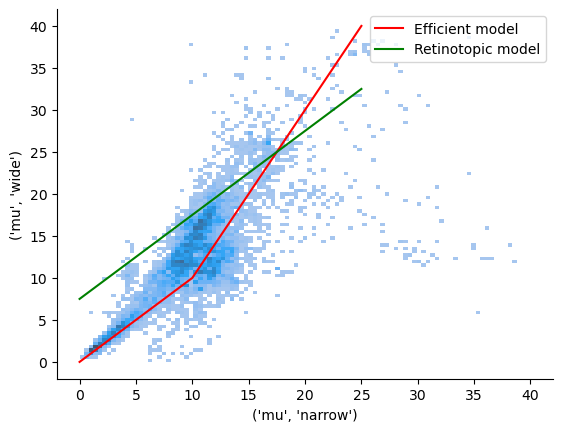

In [120]:
sns.histplot(x=pars[('mu', 'narrow')], y=pars[('mu', 'wide')], bins=[np.linspace(0, 40, 100)]*2)

plt.plot([0, 10, 25], [0, 10, 40], label='Efficient model', c='r')

plt.plot([0, 10, 25], [7.5, 17.5, 32.5], label='Retinotopic model', c='g')

plt.legend()


sns.despine()

In [125]:
from sklearn.metrics import mean_squared_error

predicted_efficient = np.where(pars[('mu', 'narrow')] < 10, pars[('mu', 'narrow')], (pars[('mu', 'narrow')] - 10) * 2 + 10)
predicted_retinotopic = pars[('mu', 'narrow')] + 7.5


print('mean_squared_error(pars[("mu", "wide")], predicted_efficient):', mean_squared_error(pars[('mu', 'wide')], predicted_efficient))
print('mean_squared_error(pars[("mu", "wide")], predicted_retinotopic):', mean_squared_error(pars[('mu', 'wide')], predicted_retinotopic))



mean_squared_error(pars[("mu", "wide")], predicted_efficient): 84.71259974657316
mean_squared_error(pars[("mu", "wide")], predicted_retinotopic): 60.8152511654401
